In [37]:
import pandas as pd

# Path to your Excel file
file_path = 'data/species_866.xlsx'

# Load only the first few rows to read column names
data_scfa = pd.read_excel(file_path, nrows=5, index_col=0)

## differet scfa producers, use different 
# Define your species of interest
scfa_species = ["Bacteroides", "Prevotella", "Coprococcus comes", "Veillonella", "Dialister", "Salmonella","Akkermansia muciniphila", "Bacteroides", "Ruminococcus", "Prevotella", "Escherichia coli", "Fusobacterium",
                "Lactobacillus", "Faecalibacterium prausnitzii", "Roseburia", "Anaerostipes caccae", "Butyrivibrio fibrisolvens", "Subdoligranulum variabile",
                "Anaerotruncus colihominis", "Eubacterium limosum", "Coprococcus"]

# Find columns that contain any of the species names
#filtered_columns = [col for col in data_butyrate.columns if any(species in col for species in butyrate_species)]

filtered_indices = [i for i, col in enumerate(data_scfa.columns, start=1) if any(species in col for species in scfa_species)]

# Include the first column index (0) with the filtered indices
use_columns = [0] + filtered_indices

# Load the entire file with only the filtered columns, setting the first column as the index
scfa_data = pd.read_excel(file_path, usecols=use_columns, index_col=0)


KeyboardInterrupt: 

In [ ]:
columns_to_drop = scfa_data.filter(regex='virus|phage').columns

# Drop these columns from the DataFrame
scfa_data =scfa_data.drop(columns=columns_to_drop)

In [ ]:
scfa_data

In [ ]:
scfa_data.to_excel('data/scfa_species800.xlsx')

In [ ]:
# change to different files scfa, acetate, propinate, butyrate

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
scfa_data = pd.read_excel("data/scfa_species800.xlsx", index_col=0)
food_data_spear = pd.read_excel('data/FFQA862.xlsx', index_col=0)
participants_data = pd.read_excel('data/ethnicity_866.xlsx', index_col=0)

In [39]:
common_indices = scfa_data.index.intersection(food_data_spear.index)
scfa_data = scfa_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [40]:
scfa_data

,Salmonella sp. 14,Salmonella sp.,Salmonella sp. SCFS4,Salmonella sp. 2018103,Salmonella sp. SSDFZ54,Salmonella sp. SJTUF14523,Salmonella sp. A7,Salmonella sp. A29-2,Salmonella sp. SJTUF14076,Salmonella sp. SJTUF14146,...,Fusobacterium necrophorum,Fusobacterium periodonticum,Fusobacterium ulcerans,Fusobacterium pseudoperiodonticum,Fusobacterium hwasookii,Fusobacterium hominis,Fusobacterium gastrosuis,Fusobacterium canifelinum,Fusobacterium sp. oral taxon 203,Bacteroides sp. CBA7301
10004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3081
10005,0,0,0,0,0,0,0,0,0,0,...,0,0,178,123,67,171,0,79,0,3783
10006,0,0,0,0,0,0,0,0,0,0,...,75,0,59,57,68,0,0,0,0,0
10012,0,0,0,0,0,0,0,0,0,0,...,0,0,31,19,0,0,0,0,0,2079
10026,0,0,0,0,0,0,0,0,0,0,...,91,0,0,0,0,0,0,0,0,1058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PSA-2971-1,0,0,0,36,0,0,0,0,0,0,...,0,0,32,0,0,0,0,0,0,930
PSA-3006-5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,825
PSA-3012-3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,41,0,0,0,0,0,664
PSA-3030-5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,742


In [41]:
# Convert data to numeric and handle non-numeric entries
scfa_data = scfa_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
#participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')

In [42]:


def adjust_for_covariates(data, covariates, categorical_vars=[]):
    # Generate dummy variables for categorical variables
    if categorical_vars:
        covariates = pd.get_dummies(covariates, columns=categorical_vars, drop_first=True)
    
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid

    return adjusted_data

# Adjust microbiome and diet data
# Ensure that 'FREG5_Ethnic_Group' is included as a categorical variable
adjusted_scfa_data = adjust_for_covariates(scfa_data, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])




In [43]:
correlations_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)
p_values_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_scfa = correlations_scfa.astype(float)  # Convert to float
p_values_scfa = p_values_scfa.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_scfa.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value


In [44]:
for microbe in adjusted_scfa_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_scfa_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_scfa_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_scfa.loc[microbe, nutrient] = corr
            p_values_scfa.loc[microbe, nutrient] = pval
        else:
            correlations_scfa.loc[microbe, nutrient] = np.nan
            p_values_scfa.loc[microbe, nutrient] = np.nan

#significant_matrix_spear, corrected_pvals_spear, _, _ = multipletests(p_values_spear.values.flatten(), alpha=0.2, method='fdr_bh')


#significant_matrix_spear = significant_matrix_spear.reshape(p_values_spear.shape)


In [61]:
p_flat = p_values_scfa.values.flatten()
reject, corrected_pvals_scfa, _, _ = multipletests(p_flat, alpha=0.1, method='fdr_bh')
significant_matrix_scfa = pd.DataFrame(reject.reshape(p_values_scfa.shape), index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_scfa.sum(axis=1)

# Filter species with at least 10 significant correlations
significant_species = true_counts >= 10
filtered_species_scfa = correlations_scfa.loc[significant_species.index[significant_species]]


In [62]:
filtered_species_scfa

,Fish,Crustacean,Mollusk,Poultry,Red_meat,Processed_meat,Dairy,Cruciferous_veg,Legumes,Mushrooms,Fruits,Papaya,Orange,Wholegrain,Chapati,Idli_Thosai,Noodle_dishes,Deep_fried,Coffee,Tea
Salmonella sp. 2018103,-0.009866,0.013004,0.193567,0.023669,-0.028846,0.234529,-0.013256,-0.001015,-0.155231,-0.142736,-0.067632,-0.170726,-0.202391,-0.103468,-0.065638,0.206530,0.085964,0.092081,0.035299,0.058112
Salmonella sp. SSDFZ54,0.025828,-0.015916,-0.079823,-0.106763,0.055090,-0.118562,0.077179,-0.028812,-0.019067,-0.114705,0.020897,0.068383,0.067826,0.118266,-0.579349,0.462181,0.031867,-0.117461,0.102536,0.113050
Salmonella sp. SJTUF14076,0.074298,0.005976,-0.115041,-0.094922,0.053819,-0.093481,0.047838,-0.043003,-0.057997,-0.016764,0.057266,0.182448,0.191284,0.190146,-0.694589,0.265721,0.009896,-0.109351,0.106337,0.016935
Salmonella sp. SJTUF14154,0.089934,-0.048104,-0.160923,-0.085464,-0.012261,-0.074835,0.067866,-0.051656,0.064584,-0.040156,0.093642,0.287401,0.111774,0.124901,-0.141193,0.152597,-0.081049,-0.054217,-0.009123,-0.046706
Salmonella sp. 3C,0.050454,-0.047907,-0.160280,-0.148593,0.021753,-0.127892,0.078830,-0.065814,-0.016930,-0.075960,0.071673,0.197269,0.179124,0.163371,-0.704227,0.391046,-0.017908,-0.119980,0.106088,0.048418
Salmonella sp. SAL-020,-0.052201,0.089056,0.124297,0.159212,0.015562,0.066293,-0.108859,0.081057,-0.009624,0.189582,-0.056372,-0.167937,-0.025291,-0.074076,0.480102,-0.564782,0.025088,0.064956,-0.075293,-0.087620
Salmonella sp. S13,0.047259,-0.036726,-0.244452,-0.097993,0.034489,-0.172038,0.077171,-0.044742,0.071265,0.029751,0.093344,0.274083,0.247038,0.167686,-0.329214,0.064792,-0.076848,-0.101677,0.029634,-0.056791
Lactobacillus gasseri,0.038919,-0.029930,-0.150886,-0.091670,0.029214,-0.138486,0.048471,-0.081479,0.032437,-0.024410,0.051945,0.184994,0.112372,0.113576,-0.318188,0.221519,-0.040754,-0.087489,0.051822,0.013789
Lactobacillus acetotolerans,0.034755,-0.084676,-0.239382,-0.138683,0.041910,-0.187177,0.116999,-0.039849,0.074553,-0.052531,0.121082,0.224278,0.185800,0.123001,-0.474205,0.332691,-0.056523,-0.112132,0.053527,0.023943
Lactobacillus amylovorus,0.042941,-0.031411,-0.242131,-0.093199,0.054832,-0.168574,0.072159,-0.054705,0.080326,0.038225,0.081341,0.253883,0.230393,0.146060,-0.287966,0.045490,-0.068414,-0.089724,0.030259,-0.053766


In [63]:
## drop phage and virus

<Figure size 1440x1440 with 0 Axes>

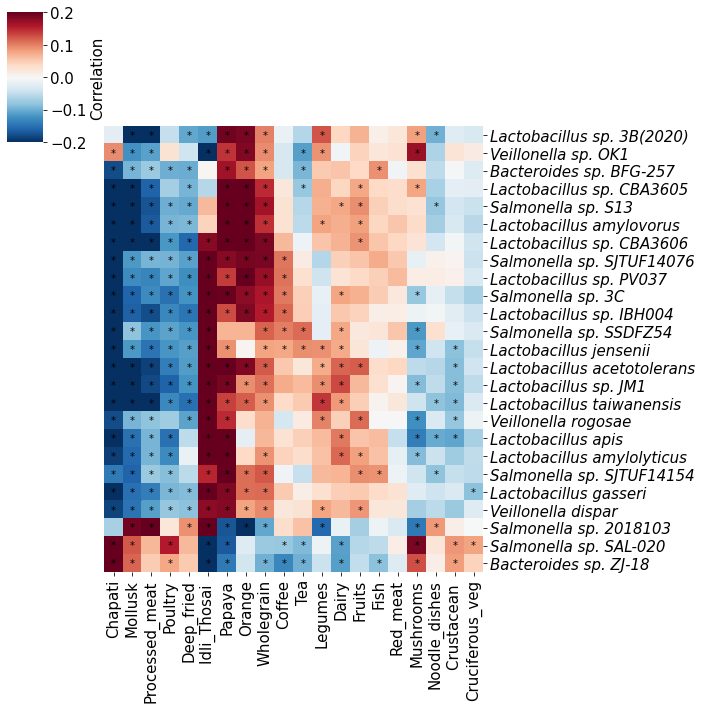

In [64]:
filtered_significance_matrix_scfa = significant_matrix_scfa.loc[filtered_species_scfa.index, filtered_species_scfa.columns]
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)


plt.figure(figsize=(20, 20))
ax = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=True)

ax.ax_row_dendrogram.set_visible(False)
ax.ax_col_dendrogram.set_visible(False)

row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new position in the clustered heatmap
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
plt.rc('font', size=15)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=15)

plt.show()

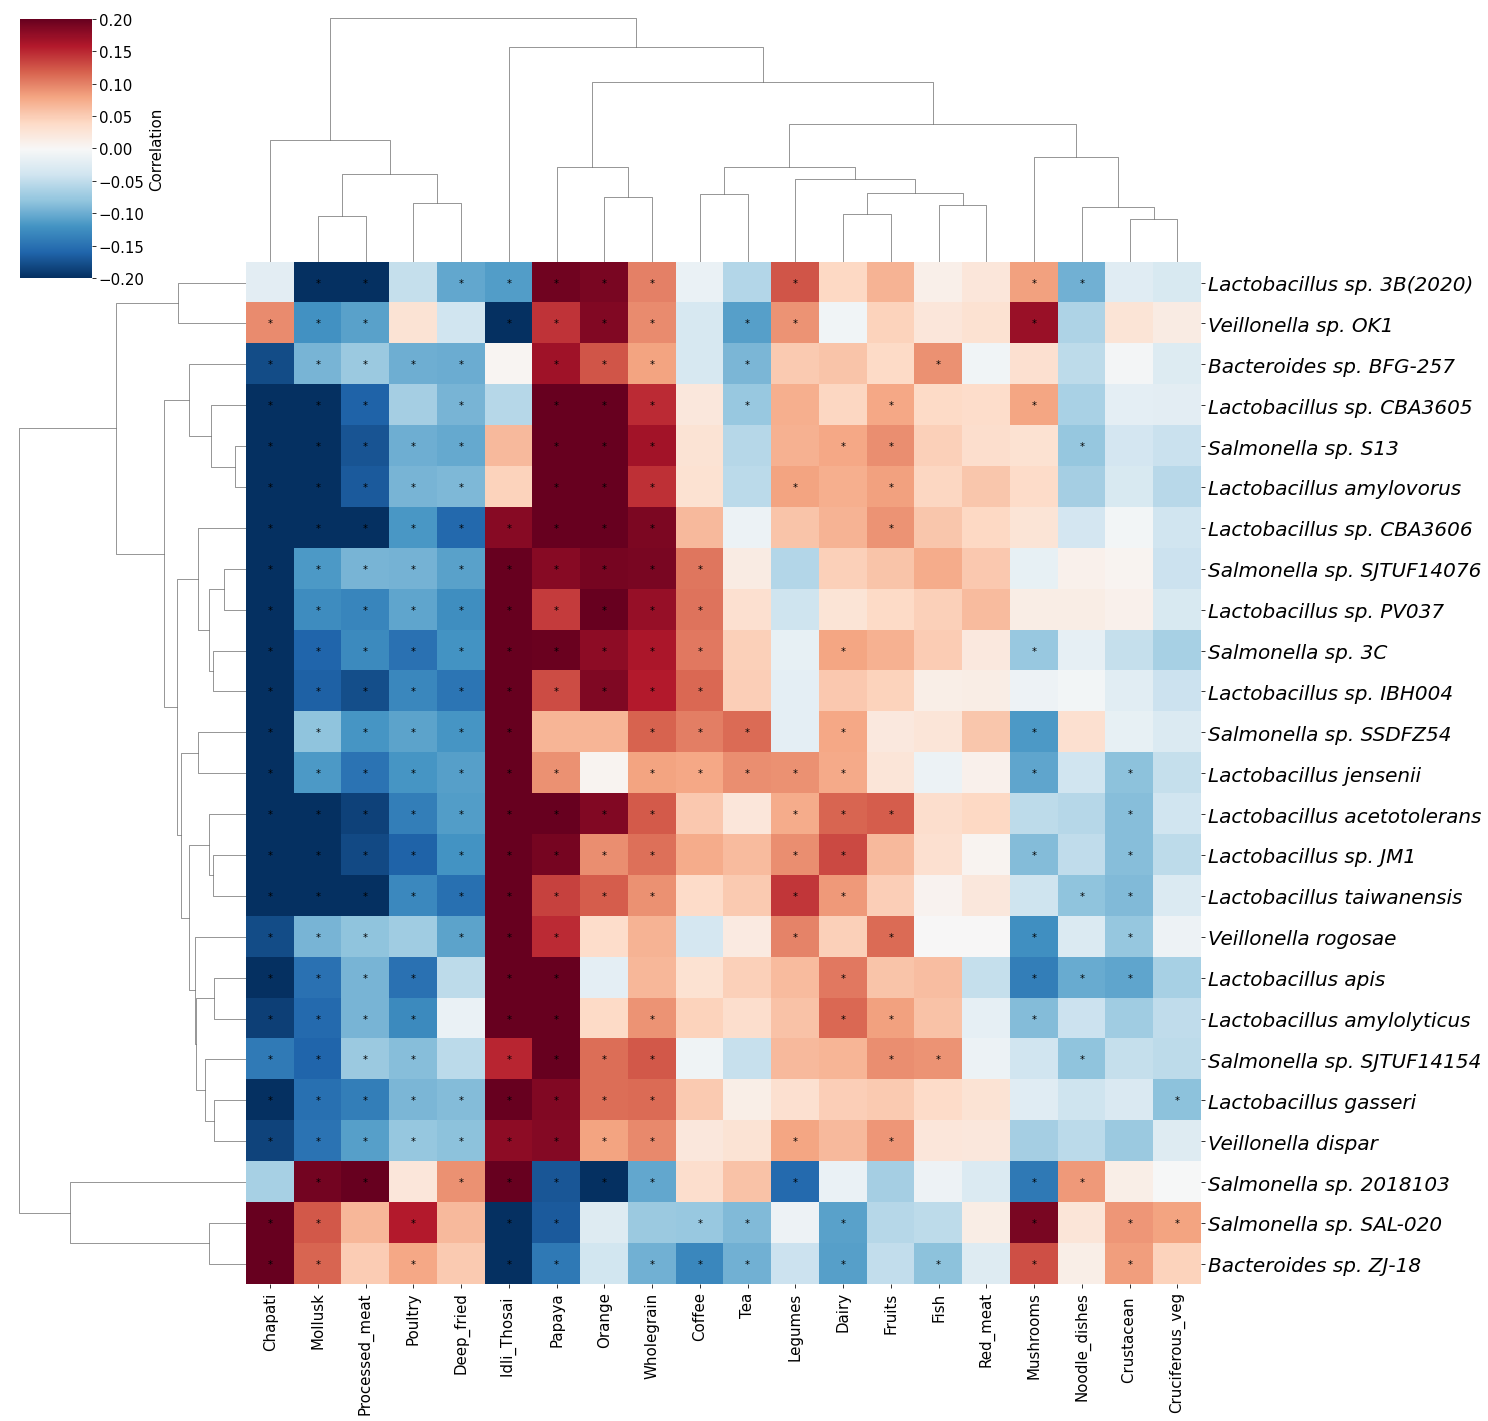

In [65]:


# Assuming filtered_species_scfa, significant_matrix_scfa are defined as per your context
# Clipping values
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap
ax = sns.clustermap(
    clipped_correlations_scfa,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=True,
    col_cluster=True,
    figsize=(20, 20)  # Adjust size directly here if needed
)

# Making dendrograms visible to check the layout
ax.ax_row_dendrogram.set_visible(True)
ax.ax_col_dendrogram.set_visible(True)

# Get the order of rows and columns after clustering
row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})
#plt.savefig('figure/food_scfa_heatmap800.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


In [66]:
#ordered_indices = ax.dendrogram_row.reordered_ind

# Print the ordered row names
#ordered_row_names = clipped_correlations_scfa.index[ordered_indices]
#print(ordered_row_names)
food_row_order = ax.dendrogram_row.reordered_ind

In [67]:
#nutrition

In [68]:

scfa_data = pd.read_excel("data/scfa_species800.xlsx", index_col=0)
food_data_spear = pd.read_excel('data/FFQB800.xlsx', index_col=0)
participants_data = pd.read_excel('data/ethnicity_866.xlsx', index_col=0)

In [69]:
common_indices = scfa_data.index.intersection(food_data_spear.index)
scfa_data = scfa_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [70]:
# Convert data to numeric and handle non-numeric entries
scfa_data = scfa_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
#participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')

In [71]:
def adjust_for_covariates(data, covariates, categorical_vars=[]):
    # Generate dummy variables for categorical variables
    if categorical_vars:
        covariates = pd.get_dummies(covariates, columns=categorical_vars, drop_first=True)
    
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid

    return adjusted_data

# Adjust microbiome and diet data
# Ensure that 'FREG5_Ethnic_Group' is included as a categorical variable
adjusted_scfa_data = adjust_for_covariates(scfa_data, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])




In [72]:
correlations_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)
p_values_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_scfa = correlations_scfa.astype(float)  # Convert to float
p_values_scfa = p_values_scfa.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_scfa.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value


In [73]:
for microbe in adjusted_scfa_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_scfa_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_scfa_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_scfa.loc[microbe, nutrient] = corr
            p_values_scfa.loc[microbe, nutrient] = pval
        else:
            correlations_scfa.loc[microbe, nutrient] = np.nan
            p_values_scfa.loc[microbe, nutrient] = np.nan

#significant_matrix_spear, corrected_pvals_spear, _, _ = multipletests(p_values_spear.values.flatten(), alpha=0.2, method='fdr_bh')


#significant_matrix_spear = significant_matrix_spear.reshape(p_values_spear.shape)


In [74]:
p_flat = p_values_scfa.values.flatten()
reject, corrected_pvals_scfa, _, _ = multipletests(p_flat, alpha=0.2, method='fdr_bh')
significant_matrix_scfa = pd.DataFrame(reject.reshape(p_values_scfa.shape), index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_scfa.sum(axis=1)

# Filter species with at least 10 significant correlations
#significant_species = true_counts >= 0
filtered_species_scfa = correlations_scfa.loc[significant_species.index[significant_species]]
#significant_species

filtered_species_scfa = filtered_species_scfa.iloc[food_row_order, :]
filtered_species_scfa

,Energy,Protein,Total_fat,Saturated_fatty_acid,MUFA,PUFA,CHO,starch,sugar,fibre,VitaminA,VitaminC,Calcium,Iron,Bcarotene,Thiamin,Riboflavin,Potassium,Zinc
Lactobacillus sp. 3B(2020),-0.024941,-0.026532,-0.025974,-0.033012,-0.026389,-0.022863,-0.028802,-0.028939,-0.021482,-0.021717,-0.026662,-0.020223,-0.007345,-0.035172,0.009484,-0.014983,-0.020520,-0.011494,-0.031501
Veillonella sp. OK1,-0.007831,-0.001105,-0.007407,-0.011928,-0.013431,-0.005763,-0.019441,-0.015462,-0.023390,-0.001673,-0.013183,0.001166,-0.014865,-0.008749,0.034738,-0.006714,-0.006041,0.008086,-0.011503
Bacteroides sp. BFG-257,-0.034286,-0.023490,-0.038221,-0.046718,-0.039737,-0.022451,-0.029377,-0.030668,-0.006599,-0.002480,-0.033490,-0.008989,0.005530,-0.010289,0.001714,0.020652,-0.009591,-0.007937,-0.029119
Lactobacillus sp. CBA3605,0.003469,0.004110,0.005721,-0.004926,0.002377,0.013523,-0.007184,-0.018189,0.017811,0.007924,0.002001,0.008144,0.019945,0.001186,0.038991,0.013988,0.012067,0.024913,-0.003482
Salmonella sp. S13,0.003366,0.005891,0.008228,-0.000797,0.004508,0.015917,-0.008840,-0.022940,0.028747,0.007805,0.010849,0.009445,0.039650,0.001706,0.034470,0.027021,0.023415,0.030820,-0.001065
Lactobacillus amylovorus,-0.000568,0.003689,-0.001077,-0.005700,-0.006144,0.004758,-0.010324,-0.018644,0.017550,0.002469,-0.003519,-0.006266,0.030911,-0.002813,0.019799,0.022417,0.014969,0.017542,-0.006406
Lactobacillus sp. CBA3606,0.006860,0.014101,0.010222,-0.011329,0.010321,0.028215,-0.001593,-0.001340,0.002457,0.025892,0.017514,0.009182,0.035812,0.013585,0.024707,0.027361,0.019809,0.025168,0.009504
Salmonella sp. SJTUF14076,0.007870,0.025474,0.013781,0.009247,0.015035,0.015390,-0.006185,-0.010755,0.011283,0.019260,0.028280,0.013600,0.035634,0.021512,0.009087,0.026632,0.028820,0.027069,0.018112
Lactobacillus sp. PV037,-0.004211,0.007323,-0.001003,-0.006248,0.000698,-0.000214,-0.014694,-0.018127,-0.005324,0.003872,0.020380,0.014861,0.015654,0.004196,0.011949,0.017031,0.011624,0.010966,0.002921
Salmonella sp. 3C,0.002924,0.011826,0.005325,-0.001372,0.007104,0.012621,-0.001212,-0.012507,0.025383,0.020147,0.018210,0.006542,0.048205,0.012418,0.000717,0.026762,0.024817,0.026470,0.008913


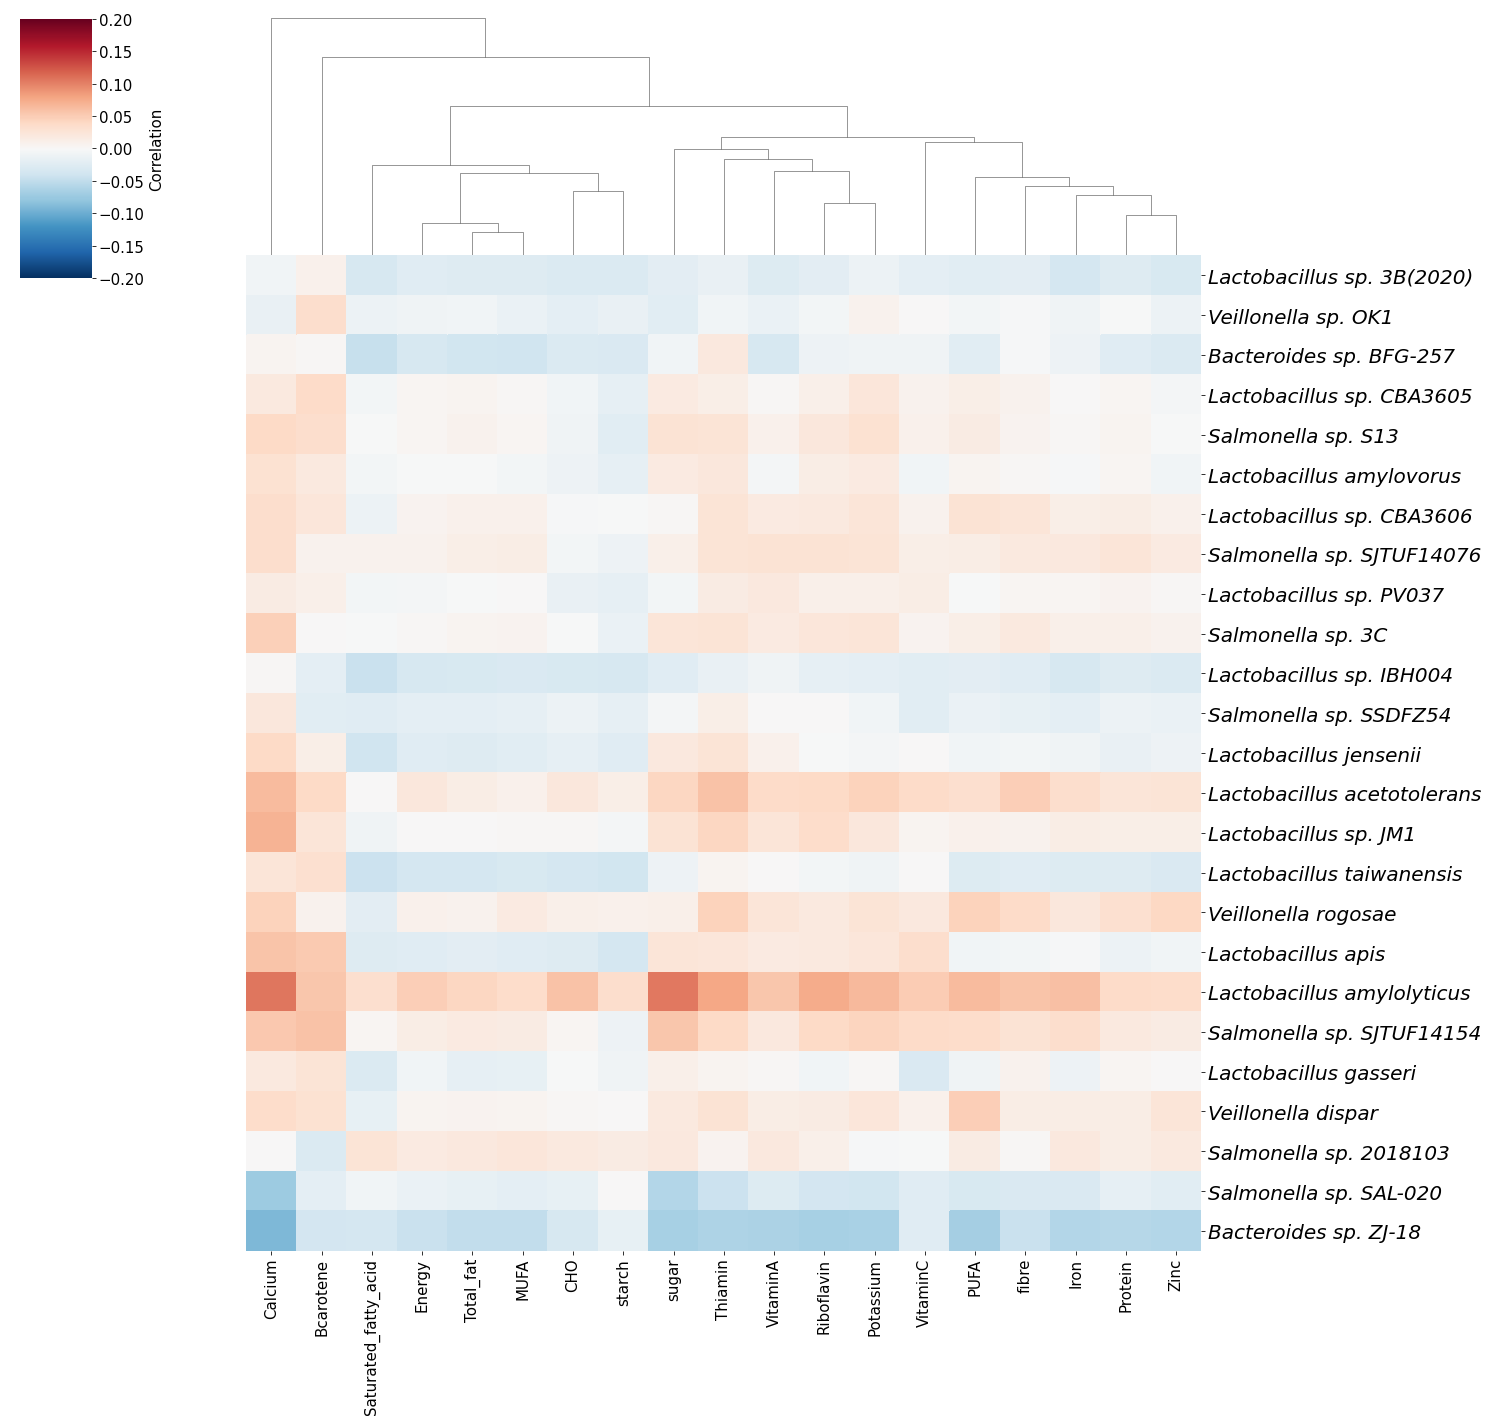

In [75]:
filtered_significance_matrix_scfa = significant_matrix_scfa.loc[filtered_species_scfa.index, filtered_species_scfa.columns]


clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap with rows in fixed order
ax = sns.clustermap(
    clipped_correlations_scfa,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=False,  # Disable row clustering
    col_cluster=True,   # Enable column clustering if desired
    figsize=(20, 20)    # Adjust size directly here if needed
)

# Since row clustering is disabled, row order is unchanged, retrieve column order
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells (adjusted for column clustering only)
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})

plt.savefig('figure/nutrition_scfa_heatmap800.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

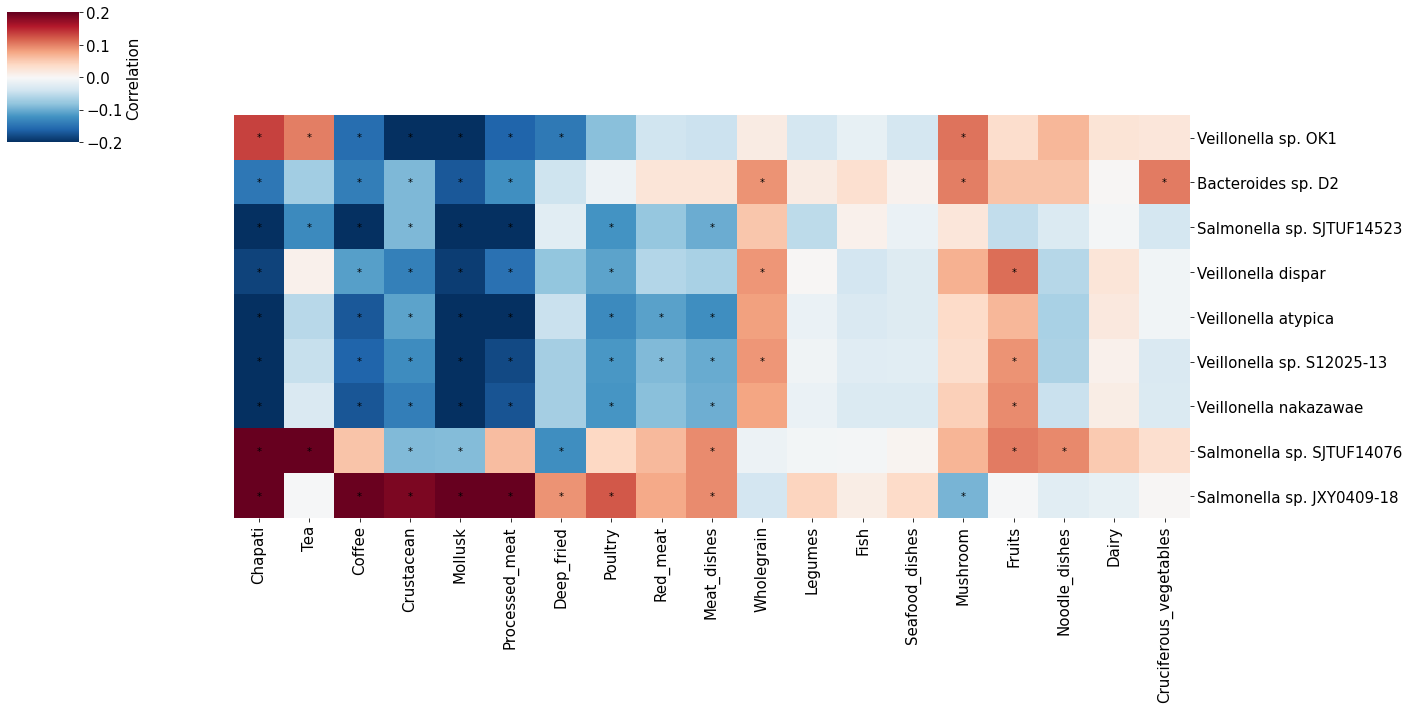

In [127]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Custom column order
custom_order = [
    'Chapati', 'Tea', 'Coffee', 'Crustacean', 'Mollusk', 'Processed_meat',
    'Deep_fried', 'Poultry', 'Red_meat', 'Meat_dishes', 'Wholegrain',
    'Legumes', 'Fish', 'Seafood_dishes', 'Mushroom', 'Fruits',
    'Noodle_dishes', 'Dairy', 'Cruciferous_vegetables'
]

# Reorder the data and significance matrix according to the custom order
filtered_species_scfa = filtered_species_scfa[custom_order]
filtered_significance_matrix_scfa = filtered_significance_matrix_scfa[custom_order]

# Clip the correlations as before
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Create a clustermap with row clustering only
cluster_grid = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=False, figsize=(20, 10))

# Hide the dendrogram for columns
cluster_grid.ax_col_dendrogram.set_visible(False)
cluster_grid.ax_row_dendrogram.set_visible(False)


# Retrieve the new order of rows after clustering
row_order = cluster_grid.dendrogram_row.reordered_ind

# Annotating with significance marks, taking into account the new row order
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new row position in the clustered heatmap
        new_i = row_order.index(i)
        cluster_grid.ax_heatmap.text(j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

plt.show()


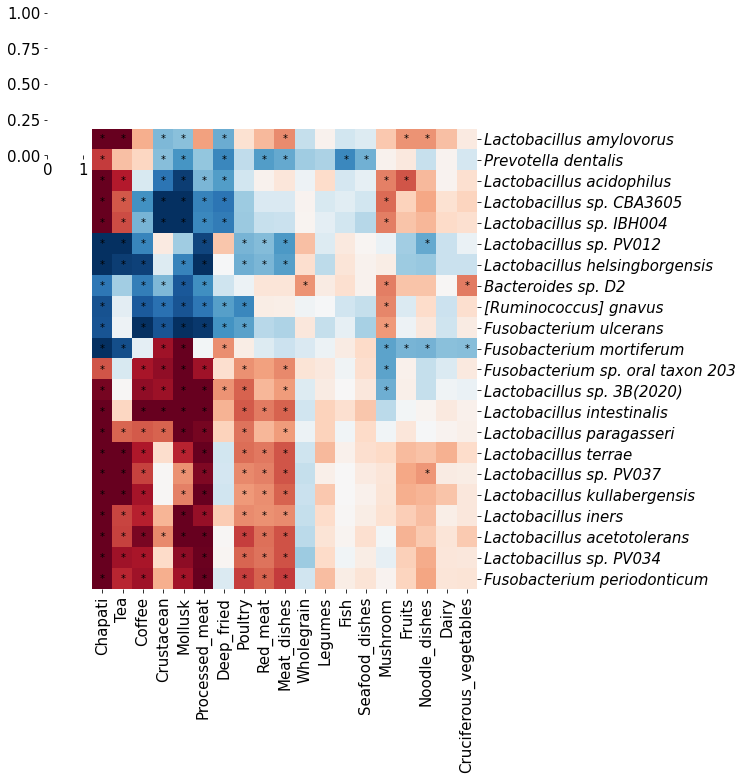

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Custom column order
custom_order = [
    'Chapati', 'Tea', 'Coffee', 'Crustacean', 'Mollusk', 'Processed_meat',
    'Deep_fried', 'Poultry', 'Red_meat', 'Meat_dishes', 'Wholegrain',
    'Legumes', 'Fish', 'Seafood_dishes', 'Mushroom', 'Fruits',
    'Noodle_dishes', 'Dairy', 'Cruciferous_vegetables'
]

# Reorder the data and significance matrix according to the custom order
filtered_species_scfa = filtered_species_scfa[custom_order]
filtered_significance_matrix_scfa = filtered_significance_matrix_scfa[custom_order]

# Clip the correlations as before
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Create a clustermap with row clustering only, no color bar, trying to make it more square-like
cluster_grid = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar=False, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=False, figsize=(10, 11), dendrogram_ratio=(.1, .2))

# Hide the dendrogram for columns
cluster_grid.ax_col_dendrogram.set_visible(False)
cluster_grid.ax_row_dendrogram.set_visible(False)

# Retrieve the new order of rows after clustering
row_order = cluster_grid.dendrogram_row.reordered_ind

# Annotating with significance marks, taking into account the new row order
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new row position in the clustered heatmap
        new_i = row_order.index(i)
        cluster_grid.ax_heatmap.text(j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in cluster_grid.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
cluster_grid.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
plt.show()


In [ ]:
## not just for scfa